In [19]:
import pandas as pd 
import numpy as np 
from prophet import Prophet


In [20]:
# Set seed for reproducibility
np.random.seed(42)

# Define number of observations and generate a date range
n = 500
dates = pd.date_range(start='2025-01-01', periods=n, freq='D')

# Create components for the synthetic data:
# - A linear trend
trend = np.linspace(0, 10, n)

# - A seasonal component using a sine wave
seasonality = 5 * np.sin(np.linspace(0, 3 * np.pi, n))

# - Random noise
noise = np.random.normal(0, 1, n)

# Combine all components to form the time series data
data = trend + seasonality + noise

# Create a DataFrame
data = pd.DataFrame({'Date': dates, 'Value': data})

In [21]:
data = data.rename(columns={'Date': 'ds', 'Value': 'y'})
data['ds'] = pd.to_datetime(data['ds'])
data.head()

,ds,y
0,2025-01-01,0.496714
1,2025-01-02,-0.023793
2,2025-01-03,0.876597
3,2025-01-04,1.866308
4,2025-01-05,0.223394


12:55:35 - cmdstanpy - INFO - Chain [1] start processing
12:55:35 - cmdstanpy - INFO - Chain [1] done processing


Mean Absolute Error (MAE): 0.7996413767542296
Root Mean Squared Error (RMSE): 1.009659071519281
Mean Absolute Percentage Error (MAPE): 65.45%
The model may require further tuning or additional data.
     Model       MAE      RMSE       MAPE
0  Prophet  0.831103  1.048985  76.341206
1  Prophet  0.811917  1.027876  70.806438
2  Prophet  0.793403  1.000562  65.362687
3  Prophet  0.799641  1.009659  65.450729


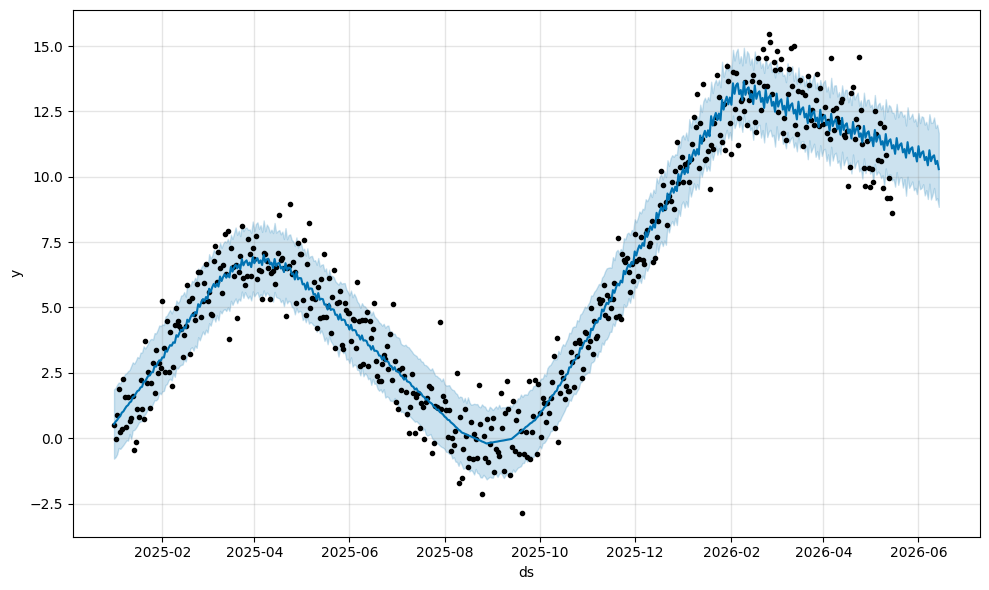

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Initialize the Prophet model
model = Prophet()
# Tune the model by adjusting hyperparameters
model = Prophet(
    seasonality_mode='multiplicative',  # Use multiplicative seasonality
    changepoint_prior_scale=0.1,        # Adjust changepoint flexibility
    seasonality_prior_scale=10.0,       # Adjust seasonality flexibility
    holidays_prior_scale=10.0           # Adjust holidays flexibility
)

#add seaonalities
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Fit the model to the data
model.fit(data)

# Create a dataframe for future predictions
future = model.make_future_dataframe(periods=30)  # Extend 30 days into the future

# Make predictions
forecast = model.predict(future)

# Plot the forecast
fig = model.plot(forecast)

# Evaluate the model on the training data
y_true = data['y'].values
y_pred = forecast.loc[forecast['ds'].isin(data['ds']), 'yhat'].values

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # Mean Absolute Percentage Error

# Print metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Interpretation
if mae < 1 and rmse < 1:
    print("The model performed well with low error metrics.")
else:
    print("The model may require further tuning or additional data.")
    
# Initialize metric_storage if not already defined
if 'metric_storage' not in locals():
    metric_storage = pd.DataFrame({
        'Model': pd.Series(dtype='str'),
        'MAE': pd.Series(dtype='float'),
        'RMSE': pd.Series(dtype='float'),
        'MAPE': pd.Series(dtype='float')
    })

# Append new results into the storage and print as dataframe
new_results = pd.DataFrame({'Model': ['Prophet'], 'MAE': [mae], 'RMSE': [rmse], 'MAPE': [mape]})
metric_storage = pd.concat([metric_storage, new_results], ignore_index=True)
print(metric_storage)




# Interpreting Metrics: MAE and RMSE

When evaluating the performance of a time series forecasting model, two commonly used metrics are **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**. Here's how to interpret these metrics:

## 1. **Mean Absolute Error (MAE)**
- **Definition**: MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It is the average of the absolute differences between predicted and actual values.
- **Interpretation**:
    - A lower MAE indicates better model performance.
    - MAE is in the same unit as the target variable, making it easy to interpret.
    - If MAE is close to 0, the model predictions are very accurate.

## 2. **Root Mean Squared Error (RMSE)**
- **Definition**: RMSE is the square root of the average of squared differences between predicted and actual values. It gives higher weight to larger errors due to squaring.
- **Interpretation**:
    - A lower RMSE indicates better model performance.
    - RMSE is also in the same unit as the target variable.
    - RMSE is sensitive to outliers; a few large errors can significantly increase its value.

## 3. **How to Determine if Metrics Are Good**
- Compare MAE and RMSE to the scale of the target variable (`y`):
    - If the target variable values range from, say, 0 to 10, an MAE or RMSE of 5 would indicate poor performance, while values closer to 0 would indicate good performance.
- **MAE vs. RMSE**:
    - If RMSE is significantly higher than MAE, it suggests the presence of large outliers in the errors.
- **Domain Knowledge**:
    - Use domain-specific knowledge to determine acceptable error thresholds. For example, in some applications, an error of 1 unit might be acceptable, while in others, even 0.1 might be too high.

## 4. **Example Interpretation**
- If MAE = 0.83 and RMSE = 1.05:
    - Both metrics are relatively low, indicating good model performance.
    - The small difference between MAE and RMSE suggests that there are no significant outliers in the errors.
    - If the target variable values range from 0 to 10, these metrics indicate that the model performs well.

Residuals Summary:
count    500.000000
mean       0.000351
std        1.010670
min       -3.166412
25%       -0.665125
50%        0.029458
75%        0.605043
max        3.433529
dtype: float64


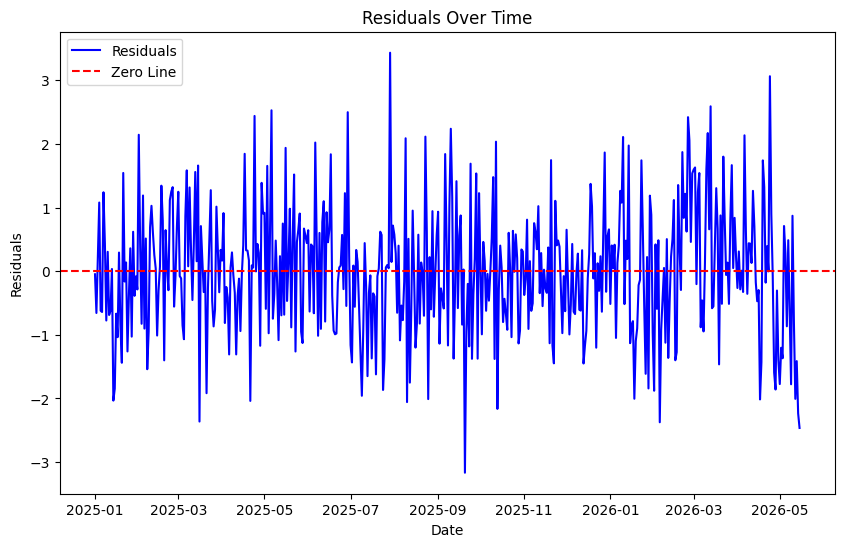

In [23]:
# Calculate residuals
residuals = y_true - y_pred

# Display basic statistics of residuals
print("Residuals Summary:")
print(pd.Series(residuals).describe())

# Optionally, plot the residuals
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(data['ds'], residuals, label='Residuals', color='blue')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.title('Residuals Over Time')
plt.legend()
plt.show()

In [24]:
from prophet.diagnostics import cross_validation, performance_metrics

# Perform cross-validation
df_cv = cross_validation(model, initial='365 days', period='180 days', horizon='30 days')

# Calculate performance metrics
df_p = performance_metrics(df_cv)

# Display the performance metrics
print(df_p)

  0%|          | 0/1 [00:00<?, ?it/s]

12:55:35 - cmdstanpy - INFO - Chain [1] start processing
12:55:36 - cmdstanpy - INFO - Chain [1] done processing


   horizon        mse      rmse       mae      mape     mdape     smape  \
0   3 days  10.248651  3.201351  3.120245  0.301770  0.320075  0.259526   
1   4 days   8.696175  2.948928  2.425322  0.242381  0.320075  0.205301   
2   5 days   3.791221  1.947106  1.321504  0.122638  0.042188  0.107634   
3   6 days   1.671982  1.293051  0.935445  0.078939  0.042188  0.073216   
4   7 days   2.495150  1.579604  1.434982  0.119970  0.128743  0.111645   
5   8 days   3.958391  1.989570  1.969718  0.166757  0.182551  0.153634   
6   9 days   2.667888  1.633367  1.549398  0.124434  0.128743  0.117410   
7  10 days   2.401639  1.549722  1.456562  0.115873  0.103060  0.109761   
8  11 days   2.197888  1.482527  1.407991  0.115024  0.103060  0.109047   
9  12 days   6.700781  2.588587  2.368142  0.216247  0.180005  0.190767   
10 13 days  11.861398  3.444038  3.317313  0.325260  0.365675  0.276090   
11 14 days  12.699693  3.563663  3.499697  0.340648  0.365675  0.288773   
12 15 days  12.917127  3.

# Interpretation of Results

This document provides an explanation of the metrics used to evaluate the performance of the forecasting model and guidelines for assessing consistency across data splits.

## Metrics

- **MAE (Mean Absolute Error):**  
    Indicates the average absolute error between predicted and actual values. Lower values signify better accuracy.

- **RMSE (Root Mean Squared Error):**  
    Represents the typical magnitude of prediction errors. Lower values are preferable as they indicate better model performance.

- **MAPE (Mean Absolute Percentage Error):**  
    Measures the percentage error relative to the actual values. Lower percentages are desirable for higher accuracy.

- **Coverage:**  
    Refers to the percentage of actual values that fall within the prediction intervals. For a 95% prediction interval, a coverage value close to 0.95 is ideal.

## Consistency Across Splits

- **Consistent Metrics:**  
    If the evaluation metrics are consistent across different data splits, it suggests that the model generalizes well to unseen data.

- **Significant Variations:**  
    If the metrics vary significantly across splits, it may indicate that the model struggles with certain subsets of the data, potentially requiring further investigation or adjustments.